# Proyecto 1 - Analítica de contratación pública

## Secretaría Distrital de Movilidad

**Integrante:** Manuela Torres

### Pregunta de negocio

¿Qué modalidades y tipos de contratación concentran la mayor parte del valor contratado por la Secretaría Distrital de Movilidad, y cómo ha cambiado esta composición a lo largo del tiempo?

### Objetivo

Realizar la exploración, limpieza y análisis de los datos de contratación de la Secretaría Distrital de Movilidad necesarios para responder la pregunta de negocio.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../Datos_completos_SDM.csv")

In [3]:
df.head()

,:id,:version,:created_at,:updated_at,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,...,n_mero_de_documento_ordenador_del_gasto,nombre_supervisor,tipo_de_documento_supervisor,n_mero_de_documento_supervisor,nombre_ordenador_de_pago,tipo_de_documento_ordenador_de_pago,n_mero_de_documento_ordenador_de_pago,documentos_tipo,descripcion_documentos_tipo,direcci_n_de_ejecuci_n_del_contrato
0,row-rd8p.mccw_35as,rv-4h3c_j643~kbx3,2026-08-23T08:01:59.248Z,2026-08-23T08:01:59.248Z,SECRETARÍA DISTRITAL DE MOVILIDAD,8999990619,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,CALLE 13 # 37 - 35 Bogotá Distrito Capital de ...
1,row-ytp4.i46b.krcd,rv-tc43~4yf6-pdh7,2026-08-23T08:01:59.248Z,2026-08-23T08:01:59.248Z,SECRETARÍA DISTRITAL DE MOVILIDAD,8999990619,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Calle 13 #37 35 Bogotá Distrito Capital de Bog...
2,row-ukeb-eb8p-rxjx,rv-58ce~cnfa-jfgw,2026-08-23T08:01:59.248Z,2026-08-23T08:01:59.248Z,SECRETARÍA DISTRITAL DE MOVILIDAD,8999990619,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Calle 13 #37 35 Bogotá Distrito Capital de Bog...
3,row-776s.tfcx.qc3k,rv-bde8~rtvj~t5du,2026-08-23T08:01:59.248Z,2026-08-23T08:01:59.248Z,SECRETARÍA DISTRITAL DE MOVILIDAD,8999990619,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,...,1026558244,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Calle 13 #37 35 Bogotá Distrito Capital de Bog...
4,row-24jh-9jqg~66bc,rv-bsfk.c598.89ej,2026-08-23T08:01:59.248Z,2026-08-23T08:01:59.248Z,SECRETARÍA DISTRITAL DE MOVILIDAD,8999990619,Distrito Capital de Bogotá,Bogotá,"Colombia, Bogotá, Bogotá",Territorial,...,No definido,No definido,No definido,No definido,No definido,No definido,No definido,No,No definido,Cl 13 No 37-35 Bogotá Distrito Capital de Bogo...


In [4]:
df.shape

(21964, 89)

In [5]:
df.columns.tolist()

[':id',
 ':version',
 ':created_at',
 ':updated_at',
 'nombre_entidad',
 'nit_entidad',
 'departamento',
 'ciudad',
 'localizaci_n',
 'orden',
 'sector',
 'rama',
 'entidad_centralizada',
 'proceso_de_compra',
 'id_contrato',
 'referencia_del_contrato',
 'estado_contrato',
 'codigo_de_categoria_principal',
 'descripcion_del_proceso',
 'tipo_de_contrato',
 'modalidad_de_contratacion',
 'justificacion_modalidad_de',
 'fecha_de_firma',
 'fecha_de_inicio_del_contrato',
 'fecha_de_fin_del_contrato',
 'condiciones_de_entrega',
 'tipodocproveedor',
 'documento_proveedor',
 'proveedor_adjudicado',
 'es_grupo',
 'es_pyme',
 'habilita_pago_adelantado',
 'liquidaci_n',
 'obligaci_n_ambiental',
 'obligaciones_postconsumo',
 'reversion',
 'origen_de_los_recursos',
 'destino_gasto',
 'valor_del_contrato',
 'valor_de_pago_adelantado',
 'valor_facturado',
 'valor_pendiente_de_pago',
 'valor_pagado',
 'valor_amortizado',
 'valor_pendiente_de',
 'valor_pendiente_de_ejecucion',
 'saldo_cdp',
 'saldo_vige

## 1. Selección de variables relevantes

Para responder la pregunta de negocio se seleccionan las variables relacionadas con la identificación del contrato, su estado, el tipo y modalidad de contratación, la fecha de firma y el valor contractual.

In [6]:
columnas_interes = [
    "id_contrato",
    "estado_contrato",
    "tipo_de_contrato",
    "modalidad_de_contratacion",
    "fecha_de_firma",
    "valor_del_contrato"
]

df_manuela = df[columnas_interes].copy()

In [7]:
df_manuela.head()

,id_contrato,estado_contrato,tipo_de_contrato,modalidad_de_contratacion,fecha_de_firma,valor_del_contrato
0,CO1.PCCNTR.484426,Aprobado,Prestación de servicios,Contratación directa,2018-07-16T00:00:00.000,29274000.0
1,CO1.PCCNTR.7507462,Modificado,Prestación de servicios,Contratación directa,2025-02-17T00:00:00.000,58662000.0
2,CO1.PCCNTR.9585745,En ejecución,Prestación de servicios,Contratación directa,2026-06-22T00:00:00.000,58399400.0
3,CO1.PCCNTR.8779592,En ejecución,Prestación de servicios,Contratación directa,2026-01-07T00:00:00.000,29822100.0
4,CO1.PCCNTR.1700821,En ejecución,Prestación de servicios,Contratación directa,2020-07-16T00:00:00.000,20574250.0


In [8]:
df_manuela.shape

(21964, 6)

## 2. Revisión de calidad de los datos

Se revisan los tipos de datos, valores faltantes, categorías y posibles registros duplicados antes de realizar cualquier transformación o análisis.

In [9]:
df_manuela.info()

<class 'pandas.DataFrame'>
RangeIndex: 21964 entries, 0 to 21963
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_contrato                21964 non-null  str    
 1   estado_contrato            21964 non-null  str    
 2   tipo_de_contrato           21964 non-null  str    
 3   modalidad_de_contratacion  21964 non-null  str    
 4   fecha_de_firma             21380 non-null  str    
 5   valor_del_contrato         21964 non-null  float64
dtypes: float64(1), str(5)
memory usage: 1.0 MB


In [10]:
df_manuela.isna().sum()

id_contrato                    0
estado_contrato                0
tipo_de_contrato               0
modalidad_de_contratacion      0
fecha_de_firma               584
valor_del_contrato             0
dtype: int64

In [11]:
(df_manuela.isna().mean() * 100).round(2)

id_contrato                  0.00
estado_contrato              0.00
tipo_de_contrato             0.00
modalidad_de_contratacion    0.00
fecha_de_firma               2.66
valor_del_contrato           0.00
dtype: float64

### Valores faltantes

La única variable seleccionada que presenta valores faltantes es `fecha_de_firma`, con 584 registros, equivalentes al 2,66 % de las observaciones.

Antes de decidir el tratamiento de estos registros, se investigará su relación con `estado_contrato`, con el fin de establecer si la ausencia de fecha de firma responde a un patrón sistemático asociado al estado del proceso contractual.

In [12]:
df_manuela["estado_contrato"].value_counts()

estado_contrato
Cerrado              7343
Modificado           5837
En ejecución         5600
Aprobado             1031
cedido                789
terminado             763
Borrador              384
Cancelado             150
enviado Proveedor      30
En aprobación          20
Suspendido             17
Name: count, dtype: int64

In [13]:
df_manuela["tipo_de_contrato"].value_counts()

tipo_de_contrato
Prestación de servicios       21348
Compraventa                     186
Otro                            143
Obra                             63
Interventoría                    50
Consultoría                      48
Suministros                      34
Seguros                          34
Decreto 092 de 2017              25
Arrendamiento de inmuebles       21
Comodato                          5
Arrendamiento de muebles          3
Servicios financieros             2
Concesión                         1
Comisión                          1
Name: count, dtype: int64

In [14]:
df_manuela["modalidad_de_contratacion"].value_counts()

modalidad_de_contratacion
Contratación directa                                           21110
Mínima cuantía                                                   257
Contratación Directa (con ofertas)                               140
Selección abreviada subasta inversa                              137
Concurso de méritos abierto                                       98
Licitación pública                                                85
Selección Abreviada de Menor Cuantía                              51
Licitación pública Obra Publica                                   50
Contratación régimen especial                                     28
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes        8
Name: count, dtype: int64

### Revisión de categorías

Se revisó la distribución de los estados, tipos y modalidades de contratación. Se observa una alta concentración en contratos de prestación de servicios y en la modalidad de contratación directa. Sin embargo, la frecuencia de contratos no necesariamente implica concentración del valor contratado, por lo que estas categorías se conservarán para su posterior análisis económico.

Antes de definir filtros sobre el estado contractual, se analizará la relación entre los estados y la disponibilidad de la fecha de firma.

In [15]:
df_manuela[df_manuela["fecha_de_firma"].isna()]["estado_contrato"].value_counts()

estado_contrato
Borrador             384
Cancelado            150
enviado Proveedor     30
En aprobación         20
Name: count, dtype: int64

In [16]:
df_manuela["id_contrato"].duplicated().sum()

np.int64(0)

In [17]:
df_manuela.duplicated().sum()

np.int64(0)

### Tratamiento de estados contractuales

Los 584 registros sin fecha de firma corresponden exclusivamente a los estados
`Borrador`, `Cancelado`, `enviado Proveedor` y `En aprobación`.

De acuerdo con el flujo de gestión contractual de SECOP II, los estados asociados al
envío al proveedor y a la aprobación corresponden a etapas previas a la firma y
publicación definitiva del contrato. Por esta razón, estos registros no se consideran
contratación formalizada y se excluyen del análisis del valor contratado.

También se verificó la existencia de duplicados tanto por `id_contrato` como por fila
completa, sin encontrarse registros duplicados.

In [18]:
estados_excluir = [
    "Borrador",
    "Cancelado",
    "enviado Proveedor",
    "En aprobación"
]

In [19]:
df_limpio = df_manuela[
    ~df_manuela["estado_contrato"].isin(estados_excluir)
].copy()

In [20]:
df_limpio.shape

(21380, 6)

In [21]:
df_limpio.isna().sum()

id_contrato                  0
estado_contrato              0
tipo_de_contrato             0
modalidad_de_contratacion    0
fecha_de_firma               0
valor_del_contrato           0
dtype: int64

### Revisión del valor del contrato

Antes de realizar el análisis económico se revisa la distribución de `valor_del_contrato` para identificar valores iguales a cero, negativos o potencialmente atípicos que puedan distorsionar los resultados agregados.

In [22]:
df_limpio["valor_del_contrato"].describe()

count    2.138000e+04
mean     1.510513e+08
std      1.358131e+09
min      0.000000e+00
25%      2.029000e+07
50%      2.982210e+07
75%      5.461000e+07
max      7.517333e+10
Name: valor_del_contrato, dtype: float64

In [23]:
(df_limpio["valor_del_contrato"] <= 0).sum()

np.int64(24)

In [24]:
df_limpio[
    ["id_contrato", "tipo_de_contrato", "modalidad_de_contratacion", "valor_del_contrato"]
].sort_values(
    "valor_del_contrato",
    ascending=False
).head(10)

,id_contrato,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato
11395,CO1.PCCNTR.8559979,Otro,Contratación Directa (con ofertas),7.517333e+10
14280,CO1.PCCNTR.7918128,Otro,Contratación Directa (con ofertas),4.615501e+10
2395,CO1.PCCNTR.2412371,Prestación de servicios,Licitación pública,4.488798e+10
5910,CO1.PCCNTR.7973611,Prestación de servicios,Licitación pública,3.845067e+10
21328,CO1.PCCNTR.6387308,Otro,Contratación Directa (con ofertas),3.519287e+10
4389,CO1.PCCNTR.7770910,Prestación de servicios,Selección abreviada subasta inversa,3.302960e+10
3370,CO1.PCCNTR.2432617,Decreto 092 de 2017,Contratación régimen especial,3.185929e+10
10391,CO1.PCCNTR.4679275,Obra,Licitación pública Obra Publica,2.832564e+10
19213,CO1.PCCNTR.7766240,Obra,Licitación pública Obra Publica,2.777025e+10
15163,CO1.PCCNTR.8716810,Prestación de servicios,Licitación pública,2.734032e+10


In [25]:
(df_limpio["valor_del_contrato"] == 0).sum()

np.int64(24)

In [26]:
(df_limpio["valor_del_contrato"] < 0).sum()

np.int64(0)

In [27]:
df_limpio[
    df_limpio["valor_del_contrato"] <= 0
][
    ["id_contrato", "estado_contrato", "tipo_de_contrato",
     "modalidad_de_contratacion", "fecha_de_firma",
     "valor_del_contrato"]
]

,id_contrato,estado_contrato,tipo_de_contrato,modalidad_de_contratacion,fecha_de_firma,valor_del_contrato
2169,CO1.PCCNTR.1490924,terminado,Consultoría,Concurso de méritos abierto,2020-04-13T00:00:00.000,0.0
4555,CO1.PCCNTR.990319,terminado,Consultoría,Concurso de méritos abierto,2019-06-10T00:00:00.000,0.0
4608,CO1.PCCNTR.1849461,terminado,Otro,Contratación Directa (con ofertas),2020-09-18T00:00:00.000,0.0
4693,CO1.PCCNTR.5146541,Modificado,Otro,Contratación directa,2023-06-27T00:00:00.000,0.0
6033,CO1.PCCNTR.3020725,Modificado,Otro,Contratación directa,2021-12-06T00:00:00.000,0.0
6192,CO1.PCCNTR.2755044,Modificado,Otro,Contratación directa,2021-08-12T00:00:00.000,0.0
6555,CO1.PCCNTR.3833493,terminado,Otro,Contratación directa,2022-07-22T00:00:00.000,0.0
6718,CO1.PCCNTR.2733162,Aprobado,Otro,Contratación directa,2021-08-05T00:00:00.000,0.0
7494,CO1.PCCNTR.2348603,terminado,Comodato,Contratación directa,2021-03-15T00:00:00.000,0.0
8596,CO1.PCCNTR.1523960,Modificado,Otro,Contratación directa,2020-04-24T00:00:00.000,0.0


### Tratamiento de contratos con valor cero

Se identificaron 24 contratos con `valor_del_contrato` igual a cero y no se encontraron valores negativos.

Los contratos con valor cero corresponden a distintos tipos, modalidades y estados contractuales, por lo que con la información seleccionada no es posible concluir que se trate de registros erróneos. Por esta razón, se conservan dentro de la base limpia.

Estos registros no afectan los análisis basados en la suma del valor contratado. Sin embargo, para análisis de distribución del monto contractual, como promedios, diagramas de caja o pruebas estadísticas, se trabajará únicamente con contratos cuyo valor sea mayor que cero.

In [28]:
df_monetario = df_limpio[
    df_limpio["valor_del_contrato"] > 0
].copy()

In [29]:
df_monetario.shape

(21356, 6)

### Transformación de la variable temporal

La variable `fecha_de_firma` se transforma a formato de fecha para permitir el análisis temporal. A partir de esta variable se crea `año`, que permitirá estudiar la evolución anual de la contratación.

In [30]:
df_limpio["fecha_de_firma"] = pd.to_datetime(
    df_limpio["fecha_de_firma"]
)

df_limpio["año"] = df_limpio["fecha_de_firma"].dt.year

In [31]:
df_monetario["fecha_de_firma"] = pd.to_datetime(
    df_monetario["fecha_de_firma"]
)

df_monetario["año"] = df_monetario["fecha_de_firma"].dt.year

In [32]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 21380 entries, 0 to 21963
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_contrato                21380 non-null  str           
 1   estado_contrato            21380 non-null  str           
 2   tipo_de_contrato           21380 non-null  str           
 3   modalidad_de_contratacion  21380 non-null  str           
 4   fecha_de_firma             21380 non-null  datetime64[us]
 5   valor_del_contrato         21380 non-null  float64       
 6   año                        21380 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(1), str(4)
memory usage: 1.2 MB


In [33]:
df_limpio["año"].value_counts().sort_index()

año
2017      19
2018    1758
2019     461
2020    2009
2021    2909
2022    2056
2023    2729
2024    3583
2025    3280
2026    2576
Name: count, dtype: int64

## 3. Análisis descriptivo de la pregunta de negocio

### Análisis por modalidad de contratación

Se analiza la distribución del número de contratos y del valor contratado entre las diferentes modalidades de contratación, con el fin de identificar cuáles concentran la mayor proporción de recursos.

In [34]:
resumen_modalidad_base = (
    df_limpio
    .groupby("modalidad_de_contratacion")
    .agg(
        numero_contratos=("id_contrato", "count"),
        valor_total=("valor_del_contrato", "sum")
    )
    .reset_index()
)

In [35]:
resumen_modalidad_base

,modalidad_de_contratacion,numero_contratos,valor_total
0,Concurso de méritos abierto,98,2.937577e+11
1,Contratación Directa (con ofertas),132,6.352612e+11
2,Contratación directa,20562,9.157979e+11
3,Contratación régimen especial,26,1.185059e+11
4,Licitación pública,83,5.230245e+11
5,Licitación pública Obra Publica,46,5.383319e+11
6,Mínima cuantía,247,7.757456e+09
7,Seleccion Abreviada Menor Cuantia Sin Manifest...,7,5.159660e+10
8,Selección Abreviada de Menor Cuantía,48,2.414300e+10
9,Selección abreviada subasta inversa,131,1.213019e+11


In [36]:
resumen_modalidad_monetario = (
    df_monetario
    .groupby("modalidad_de_contratacion")
    .agg(
        valor_promedio=("valor_del_contrato", "mean"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .reset_index()
)

In [37]:
resumen_modalidad = resumen_modalidad_base.merge(
    resumen_modalidad_monetario,
    on="modalidad_de_contratacion",
    how="left"
)

In [38]:
resumen_modalidad["participacion_valor_pct"] = (
    resumen_modalidad["valor_total"]
    / resumen_modalidad["valor_total"].sum()
    * 100
)

In [39]:
resumen_modalidad["participacion_contratos_pct"] = (
    resumen_modalidad["numero_contratos"]
    / resumen_modalidad["numero_contratos"].sum()
    * 100
)

In [40]:
resumen_modalidad = resumen_modalidad.sort_values(
    "valor_total",
    ascending=False
)

In [41]:
resumen_modalidad

,modalidad_de_contratacion,numero_contratos,valor_total,valor_promedio,valor_mediano,participacion_valor_pct,participacion_contratos_pct
2,Contratación directa,20562,9.157979e+11,4.457956e+07,2.982210e+07,28.357459,96.173994
1,Contratación Directa (con ofertas),132,6.352612e+11,4.849322e+09,1.235115e+09,19.670710,0.617399
5,Licitación pública Obra Publica,46,5.383319e+11,1.170287e+10,7.957500e+09,16.669316,0.215154
4,Licitación pública,83,5.230245e+11,6.301500e+09,2.572534e+09,16.195326,0.388213
0,Concurso de méritos abierto,98,2.937577e+11,3.092186e+09,1.729543e+09,9.096136,0.458372
9,Selección abreviada subasta inversa,131,1.213019e+11,9.259683e+08,3.120001e+08,3.756083,0.612722
3,Contratación régimen especial,26,1.185059e+11,4.740234e+09,1.896794e+09,3.669505,0.121609
7,Seleccion Abreviada Menor Cuantia Sin Manifest...,7,5.159660e+10,7.370943e+09,4.488487e+09,1.597676,0.032741
8,Selección Abreviada de Menor Cuantía,48,2.414300e+10,5.029791e+08,2.988325e+08,0.747582,0.224509
6,Mínima cuantía,247,7.757456e+09,3.140670e+07,2.000000e+07,0.240208,1.155285


### Hallazgos preliminares por modalidad de contratación

La modalidad de `Contratación directa` concentra aproximadamente el 96 % del número total de contratos, pero representa cerca del 28 % del valor contratado.

En contraste, modalidades como `Licitación pública Obra Pública` y `Licitación pública` representan una proporción muy reducida del número de contratos, pero concentran cerca del 17 % y 16 % del valor contratado, respectivamente.

Esto evidencia una diferencia importante entre la frecuencia contractual y la concentración económica: las modalidades con mayor número de contratos no son necesariamente las que concentran los contratos de mayor valor.

### Análisis por tipo de contrato

Se analiza la distribución del número de contratos y del valor contratado entre los diferentes tipos de contrato, con el fin de identificar cuáles concentran la mayor proporción de recursos.

In [42]:
resumen_tipo_base = (
    df_limpio
    .groupby("tipo_de_contrato")
    .agg(
        numero_contratos=("id_contrato", "count"),
        valor_total=("valor_del_contrato", "sum")
    )
    .reset_index()
)

In [43]:
resumen_tipo_monetario = (
    df_monetario
    .groupby("tipo_de_contrato")
    .agg(
        valor_promedio=("valor_del_contrato", "mean"),
        valor_mediano=("valor_del_contrato", "median")
    )
    .reset_index()
)

In [44]:
resumen_tipo = resumen_tipo_base.merge(
    resumen_tipo_monetario,
    on="tipo_de_contrato",
    how="left"
)

In [45]:
resumen_tipo["participacion_valor_pct"] = (
    resumen_tipo["valor_total"]
    / resumen_tipo["valor_total"].sum()
    * 100
)

resumen_tipo["participacion_contratos_pct"] = (
    resumen_tipo["numero_contratos"]
    / resumen_tipo["numero_contratos"].sum()
    * 100
)

In [46]:
resumen_tipo = resumen_tipo.sort_values(
    "valor_total",
    ascending=False
)

In [47]:
resumen_tipo

,tipo_de_contrato,numero_contratos,valor_total,valor_promedio,valor_mediano,participacion_valor_pct,participacion_contratos_pct
11,Prestación de servicios,20792,1.325546e+12,6.375574e+07,2.982210e+07,4.104520e+01,97.249766
10,Otro,137,6.115409e+11,5.012630e+09,9.299065e+08,1.893622e+01,0.640786
9,Obra,59,6.103131e+11,1.034429e+10,6.200000e+09,1.889820e+01,0.275959
8,Interventoría,50,1.723741e+11,3.447482e+09,2.401578e+09,5.337523e+00,0.233863
12,Seguros,32,1.662361e+11,5.194878e+09,1.287049e+09,5.147461e+00,0.149673
6,Consultoría,48,1.213836e+11,2.697413e+09,1.201720e+09,3.758613e+00,0.224509
7,Decreto 092 de 2017,23,1.074253e+11,4.670666e+09,1.884012e+09,3.326399e+00,0.107577
4,Compraventa,175,7.918578e+10,4.524902e+08,9.862000e+07,2.451969e+00,0.818522
14,Suministros,33,1.751010e+10,5.306091e+08,5.472213e+07,5.421960e-01,0.154350
0,Arrendamiento de inmuebles,19,1.231829e+10,6.483309e+08,1.182257e+08,3.814328e-01,0.088868


### Hallazgos preliminares por tipo de contrato

La contratación presenta una fuerte concentración en términos de frecuencia: los contratos de prestación de servicios representan aproximadamente el 97 % del total. Sin embargo, concentran cerca del 41 % del valor contratado.

En contraste, tipos como `Obra` y `Otro` representan una proporción muy reducida del número de contratos, pero cada uno concentra cerca del 19 % del valor total. Esto evidencia que la frecuencia contractual y la concentración económica presentan patrones diferentes.

Los contratos de tipo `Comodato` presentan valor contractual igual a cero, por lo que no cuentan con promedio ni mediana dentro del subconjunto de contratos con valor positivo.

### Análisis de la evolución temporal

Para analizar cómo ha cambiado la composición de la contratación a lo largo del tiempo, se estudia la participación anual del valor contratado según la modalidad y el tipo de contrato.

El análisis permite identificar si determinadas categorías han ganado o perdido participación dentro del valor contratado por la Secretaría Distrital de Movilidad a través de los años.

Se debe tener en cuenta que 2026 corresponde a un año parcial dentro de la base de datos, por lo que sus resultados no son directamente comparables con los de años completos.

In [48]:
evolucion_modalidad = (
    df_limpio
    .groupby(["año", "modalidad_de_contratacion"])
    .agg(
        numero_contratos=("id_contrato", "count"),
        valor_total=("valor_del_contrato", "sum")
    )
    .reset_index()
)

In [49]:
evolucion_modalidad.head(20)

,año,modalidad_de_contratacion,numero_contratos,valor_total
0,2017,Concurso de méritos abierto,6,1.320218e+10
1,2017,Contratación Directa (con ofertas),2,9.934545e+09
2,2017,Licitación pública,10,4.746010e+10
3,2017,Selección Abreviada de Menor Cuantía,1,5.827135e+09
4,2018,Concurso de méritos abierto,19,4.531875e+10
5,2018,Contratación Directa (con ofertas),21,4.079972e+10
6,2018,Contratación directa,1660,4.042705e+10
7,2018,Contratación régimen especial,3,1.108053e+10
8,2018,Licitación pública,11,1.925114e+10
9,2018,Mínima cuantía,22,3.921973e+08


In [50]:
total_anual = (
    df_limpio
    .groupby("año")
    .agg(
        valor_total_anual=("valor_del_contrato", "sum")
    )
    .reset_index()
)

In [51]:
total_anual

,año,valor_total_anual
0,2017,7.642396e+10
1,2018,1.695223e+11
2,2019,1.739093e+11
3,2020,1.257528e+11
4,2021,6.359354e+11
5,2022,2.633004e+11
6,2023,2.741958e+11
7,2024,5.832473e+11
8,2025,7.446223e+11
9,2026,1.825684e+11


In [52]:
evolucion_modalidad = evolucion_modalidad.merge(
    total_anual,
    on="año",
    how="left"
)

In [53]:
evolucion_modalidad["participacion_valor_pct"] = (
    evolucion_modalidad["valor_total"]
    / evolucion_modalidad["valor_total_anual"]
    * 100
)

In [54]:
evolucion_modalidad.head(20)

,año,modalidad_de_contratacion,numero_contratos,valor_total,valor_total_anual,participacion_valor_pct
0,2017,Concurso de méritos abierto,6,1.320218e+10,7.642396e+10,17.274926
1,2017,Contratación Directa (con ofertas),2,9.934545e+09,7.642396e+10,12.999255
2,2017,Licitación pública,10,4.746010e+10,7.642396e+10,62.101071
3,2017,Selección Abreviada de Menor Cuantía,1,5.827135e+09,7.642396e+10,7.624749
4,2018,Concurso de méritos abierto,19,4.531875e+10,1.695223e+11,26.733215
5,2018,Contratación Directa (con ofertas),21,4.079972e+10,1.695223e+11,24.067468
6,2018,Contratación directa,1660,4.042705e+10,1.695223e+11,23.847636
7,2018,Contratación régimen especial,3,1.108053e+10,1.695223e+11,6.536325
8,2018,Licitación pública,11,1.925114e+10,1.695223e+11,11.356114
9,2018,Mínima cuantía,22,3.921973e+08,1.695223e+11,0.231354


In [55]:
evolucion_modalidad.groupby("año")["participacion_valor_pct"].sum().round(2)

año
2017    100.0
2018    100.0
2019    100.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024    100.0
2025    100.0
2026    100.0
Name: participacion_valor_pct, dtype: float64

In [56]:
tabla_modalidad_anual = evolucion_modalidad.pivot(
    index="año",
    columns="modalidad_de_contratacion",
    values="participacion_valor_pct"
).fillna(0).round(2)

tabla_modalidad_anual

modalidad_de_contratacion,Concurso de méritos abierto,Contratación Directa (con ofertas),Contratación directa,Contratación régimen especial,Licitación pública,Licitación pública Obra Publica,Mínima cuantía,Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,Selección Abreviada de Menor Cuantía,Selección abreviada subasta inversa
año,,,,,,,,,,
2017,17.27,13.00,0.00,0.00,62.10,0.00,0.00,0.00,7.62,0.00
2018,26.73,24.07,23.85,6.54,11.36,0.00,0.23,0.00,0.84,6.39
2019,17.18,11.78,6.65,0.00,18.61,33.37,0.27,4.20,0.48,7.47
2020,2.81,29.23,40.53,4.98,14.22,1.41,0.35,0.00,0.36,6.12
2021,8.13,15.29,16.65,9.63,15.11,26.95,0.13,6.96,0.19,0.96
2022,17.35,19.28,34.01,4.65,19.15,2.57,0.33,0.00,0.85,1.81
2023,0.96,22.28,46.01,0.56,7.44,16.07,0.58,0.00,1.60,4.50
2024,10.57,19.79,27.35,2.91,8.10,27.71,0.16,0.00,0.69,2.72
2025,4.66,26.99,30.59,0.99,20.65,8.97,0.18,0.00,0.27,6.70


#### Hallazgos preliminares de la evolución por modalidad

La composición del valor contratado presenta variaciones importantes entre años. La participación de `Contratación directa`, por ejemplo, pasa de 6,65 % en 2019 a 40,53 % en 2020 y alcanza 46,01 % en 2023, mientras que otras modalidades como `Licitación pública Obra Pública` muestran participaciones elevadas en años específicos.

Estos resultados sugieren que la concentración del valor contratado por modalidad no sigue una estructura constante, sino que cambia de manera considerable a lo largo del tiempo.

Los resultados de 2026 deben interpretarse con precaución debido a que corresponden a un año parcial dentro de la base de datos.

In [57]:
evolucion_tipo = (
    df_limpio
    .groupby(["año", "tipo_de_contrato"])
    .agg(
        numero_contratos=("id_contrato", "count"),
        valor_total=("valor_del_contrato", "sum")
    )
    .reset_index()
)

In [58]:
evolucion_tipo = evolucion_tipo.merge(
    total_anual,
    on="año",
    how="left"
)

In [59]:
evolucion_tipo["participacion_valor_pct"] = (
    evolucion_tipo["valor_total"]
    / evolucion_tipo["valor_total_anual"]
    * 100
)

In [60]:
evolucion_tipo.groupby("año")["participacion_valor_pct"].sum().round(2)

año
2017    100.0
2018    100.0
2019    100.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024    100.0
2025    100.0
2026    100.0
Name: participacion_valor_pct, dtype: float64

In [61]:
evolucion_tipo

,año,tipo_de_contrato,numero_contratos,valor_total,valor_total_anual,participacion_valor_pct
0,2017,Consultoría,3,1.111854e+10,7.642396e+10,14.548495
1,2017,Interventoría,3,2.083646e+09,7.642396e+10,2.726431
2,2017,Obra,9,4.394371e+10,7.642396e+10,57.499911
3,2017,Prestación de servicios,4,1.927807e+10,7.642396e+10,25.225163
4,2018,Arrendamiento de inmuebles,3,9.011593e+08,1.695223e+11,0.531588
...,...,...,...,...,...,...
95,2026,Obra,2,2.788179e+10,1.825684e+11,15.271970
96,2026,Otro,1,4.207440e+08,1.825684e+11,0.230458
97,2026,Prestación de servicios,2553,1.109235e+11,1.825684e+11,60.757212
98,2026,Seguros,4,3.316967e+10,1.825684e+11,18.168353


In [62]:
tabla_tipo_anual = evolucion_tipo.pivot(
    index="año",
    columns="tipo_de_contrato",
    values="participacion_valor_pct"
).fillna(0).round(2)

tabla_tipo_anual

tipo_de_contrato,Arrendamiento de inmuebles,Arrendamiento de muebles,Comisión,Comodato,Compraventa,Concesión,Consultoría,Decreto 092 de 2017,Interventoría,Obra,Otro,Prestación de servicios,Seguros,Servicios financieros,Suministros
año,,,,,,,,,,,,,,,
2017,0.00,0.00,0.00,0.0,0.00,0.0,14.55,0.00,2.73,57.50,0.00,25.23,0.00,0.00,0.00
2018,0.53,0.02,3.26,0.0,1.03,0.0,8.06,0.00,18.67,0.23,27.50,37.00,3.46,0.00,0.22
2019,0.00,0.02,0.00,0.0,2.24,0.0,7.00,0.00,10.18,33.58,12.55,30.10,4.07,0.00,0.25
2020,0.64,0.01,0.00,0.0,2.76,0.0,1.62,4.98,1.19,1.41,29.13,47.09,10.90,0.02,0.26
2021,0.17,0.00,0.00,0.0,1.03,0.0,2.83,9.63,5.30,31.24,14.63,30.26,4.90,0.00,0.01
2022,0.22,0.00,0.00,0.0,4.72,0.0,13.13,4.65,4.23,2.57,19.56,50.78,0.14,0.00,0.02
2023,0.50,0.00,0.00,0.0,2.80,0.0,0.75,0.56,0.21,16.07,20.16,50.09,5.98,0.00,2.87
2024,0.17,0.00,0.00,0.0,1.48,0.0,3.48,2.91,7.09,27.71,20.91,29.05,5.94,0.00,1.26
2025,0.88,0.00,0.00,0.0,4.30,0.0,1.01,0.99,3.66,8.97,24.75,52.13,3.20,0.00,0.12


#### Hallazgos preliminares de la evolución por tipo de contrato

La composición del valor contratado por tipo de contrato presenta cambios importantes a lo largo del tiempo. En los primeros años del periodo, los contratos de `Obra` tuvieron una participación relevante, llegando a representar el 57,50 % del valor contratado en 2017 y el 33,58 % en 2019.

Posteriormente, los contratos de `Prestación de servicios` adquieren una mayor participación. Este tipo concentra el 47,09 % del valor en 2020 y supera el 50 % en 2022, 2023 y 2025. Sin embargo, la composición no es uniforme: en 2024 el valor se distribuye de forma más equilibrada entre `Prestación de servicios`, `Obra` y `Otro`.

En conjunto, los resultados muestran que la composición económica de la contratación varía considerablemente entre años y que la alta frecuencia de los contratos de prestación de servicios no implica una concentración constante del valor durante todo el periodo analizado.

Los resultados correspondientes a 2026 deben interpretarse con precaución debido a que corresponden a un año parcial dentro de la base de datos.

## 4. Revisión de valores atípicos y potencialmente anómalos

Antes de realizar las visualizaciones definitivas, se revisa la distribución de
`valor_del_contrato` con el fin de identificar valores atípicos y registros
potencialmente anómalos.

La identificación de un valor atípico no implica que el registro sea incorrecto.
En particular, los contratos de gran valor pueden corresponder a operaciones reales
y son relevantes para el análisis de concentración económica. Por esta razón, los
valores extremos se inspeccionan antes de tomar cualquier decisión de exclusión.

In [63]:
df_monetario[
    [
        "id_contrato",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato"
    ]
].sort_values(
    "valor_del_contrato",
    ascending=True
).head(20)

,id_contrato,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato
15363,CO1.PCCNTR.7426721,Consultoría,Concurso de méritos abierto,0.1
16971,CO1.PCCNTR.3061734,Concesión,Licitación pública,1.0
15134,CO1.PCCNTR.451565,Prestación de servicios,Mínima cuantía,435000.0
10634,CO1.PCCNTR.7870631,Prestación de servicios,Contratación directa,690000.0
14415,CO1.PCCNTR.3713149,Prestación de servicios,Mínima cuantía,821100.0
15551,CO1.PCCNTR.7060692,Prestación de servicios,Mínima cuantía,850000.0
891,CO1.PCCNTR.9487745,Prestación de servicios,Mínima cuantía,880000.0
2733,CO1.PCCNTR.692096,Suministros,Contratación Directa (con ofertas),958000.0
8713,CO1.PCCNTR.2381418,Prestación de servicios,Mínima cuantía,963900.0
20472,CO1.PCCNTR.1928658,Prestación de servicios,Mínima cuantía,1106224.0


In [64]:
umbrales_bajos = {
    "Menor o igual a $1.000": (df_monetario["valor_del_contrato"] <= 1_000).sum(),
    "Menor o igual a $100.000": (df_monetario["valor_del_contrato"] <= 100_000).sum(),
    "Menor o igual a $1.000.000": (df_monetario["valor_del_contrato"] <= 1_000_000).sum()
}

umbrales_bajos

{'Menor o igual a $1.000': np.int64(2),
 'Menor o igual a $100.000': np.int64(2),
 'Menor o igual a $1.000.000': np.int64(9)}

#### Inspección de valores monetarios potencialmente anómalos

La revisión de los valores positivos más bajos identificó dos contratos con valores
particularmente reducidos (`0.1` y `1.0`), considerablemente alejados del resto de
los registros.

Antes de considerar su exclusión, se revisa información adicional de estos contratos
en la base original para determinar si los valores pueden estar asociados a las
características del proceso contractual o si corresponden a posibles anomalías de
registro.

In [65]:
ids_sospechosos = (
    df_monetario
    .sort_values("valor_del_contrato")
    .head(2)["id_contrato"]
)

ids_sospechosos

15363    CO1.PCCNTR.7426721
16971    CO1.PCCNTR.3061734
Name: id_contrato, dtype: str

In [66]:
df[
    df["id_contrato"].isin(ids_sospechosos)
][
    [
        "id_contrato",
        "estado_contrato",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "descripcion_del_proceso",
        "objeto_del_contrato",
        "fecha_de_firma",
        "valor_del_contrato"
    ]
]

,id_contrato,estado_contrato,tipo_de_contrato,modalidad_de_contratacion,descripcion_del_proceso,objeto_del_contrato,fecha_de_firma,valor_del_contrato
15363,CO1.PCCNTR.7426721,En ejecución,Consultoría,Concurso de méritos abierto,CONTRATAR LOS SERVICIOS DE INTERMEDIACIÓN DE S...,CONTRATAR LOS SERVICIOS DE INTERMEDIACIÓN DE S...,2025-02-13T00:00:00.000,0.1
16971,CO1.PCCNTR.3061734,Modificado,Concesión,Licitación pública,Entregar en concesión la prestación de los ser...,Entregar en concesión la prestación de los ser...,2021-11-30T00:00:00.000,1.0


#### Decisión sobre los valores monetarios mínimos

Los dos valores positivos más bajos corresponden a contratos de naturaleza particular:
una consultoría de intermediación de seguros con valor registrado de `0.1` y una
concesión con valor registrado de `1.0`.

La revisión del objeto contractual y de otras variables monetarias de la base original
no permite concluir que estos registros correspondan a errores de digitación. Por esta
razón, se conservan en la base de análisis y se clasifican como valores atípicos que
deben interpretarse con precaución.

### Detección estadística de valores atípicos mediante IQR

Se utiliza el rango intercuartílico (IQR) para identificar observaciones que se
encuentran alejadas del rango central de la distribución de `valor_del_contrato`.

Los valores identificados mediante este criterio se consideran valores atípicos
estadísticos, pero no necesariamente errores. Debido a la naturaleza de la contratación
pública, contratos de gran valor pueden ser legítimos y relevantes para el análisis de
concentración económica.

In [67]:
Q1 = df_monetario["valor_del_contrato"].quantile(0.25)
Q3 = df_monetario["valor_del_contrato"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

Q1, Q3, IQR, limite_inferior, limite_superior

(np.float64(20290000.0),
 np.float64(54670000.0),
 np.float64(34380000.0),
 np.float64(-31280000.0),
 np.float64(106240000.0))

#### Cuantificación de valores atípicos según el criterio IQR

A partir de los límites calculados mediante el rango intercuartílico, se identifica
cuántos contratos se encuentran por debajo del límite inferior o por encima del
límite superior.

Esta clasificación se utiliza únicamente como herramienta de diagnóstico. Los
contratos identificados como valores atípicos no serán eliminados automáticamente,
pues los montos elevados pueden corresponder a contratos legítimos y ser relevantes
para el análisis de concentración económica.

In [68]:
outliers_inferiores = df_monetario[
    df_monetario["valor_del_contrato"] < limite_inferior
]

outliers_superiores = df_monetario[
    df_monetario["valor_del_contrato"] > limite_superior
]

In [69]:
len(outliers_inferiores), len(outliers_superiores)

(0, 1724)

In [70]:
porcentaje_outliers_superiores = (
    len(outliers_superiores)
    / len(df_monetario)
    * 100
)

round(porcentaje_outliers_superiores, 2)

8.07

#### Interpretación de los valores atípicos identificados

El criterio IQR identificó 1.724 contratos con valores superiores al límite de
$106,24 millones, equivalentes aproximadamente al 8,07 % de los contratos con
valor positivo.

No se identificaron valores atípicos inferiores mediante este criterio, debido a
que el límite inferior calculado fue negativo.

Dado que los contratos de alto valor pueden corresponder a operaciones legítimas
y son especialmente relevantes para el análisis de concentración económica, estos
registros se conservan. La clasificación como valor atípico se utiliza únicamente
como una herramienta descriptiva de la distribución.

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Visualización de la distribución en escala logarítmica

Debido a la elevada asimetría de `valor_del_contrato` y a la presencia de contratos con valores de varios órdenes de magnitud, una representación en escala lineal dificulta la interpretación del diagrama de caja.

Por esta razón, el diagrama de caja se calcula sobre los valores originales de `valor_del_contrato` y únicamente el eje horizontal se presenta en escala logarítmica. Las etiquetas del eje se muestran nuevamente en valores monetarios para facilitar su interpretación.

Los valores originales no son transformados; el criterio IQR utilizado para identificar valores atípicos también se calculó sobre estos valores originales.

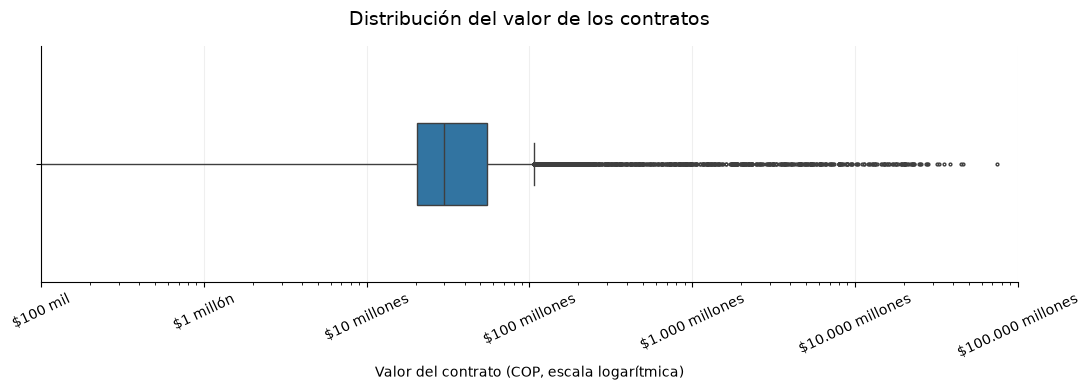

In [72]:
plt.figure(figsize=(11, 4))

ax = sns.boxplot(
    data=df_monetario,
    x="valor_del_contrato",
    width=0.35,
    fliersize=2
)

# El dato sigue estando expresado en pesos.
# Solo cambia la forma en que se representa el eje.
ax.set_xscale("log")

ticks = [
    100_000,
    1_000_000,
    10_000_000,
    100_000_000,
    1_000_000_000,
    10_000_000_000,
    100_000_000_000
]

labels = [
    "$100 mil",
    "$1 millón",
    "$10 millones",
    "$100 millones",
    "$1.000 millones",
    "$10.000 millones",
    "$100.000 millones"
]

plt.xticks(ticks, labels, rotation=25)

# Zoom para facilitar la lectura
plt.xlim(100_000, 100_000_000_000)

plt.title(
    "Distribución del valor de los contratos",
    fontsize=14,
    pad=15
)

plt.xlabel("Valor del contrato (COP, escala logarítmica)")
plt.ylabel("")

plt.grid(axis="x", alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación de la distribución del valor contractual

El diagrama de caja se presenta con el eje horizontal en escala logarítmica para
facilitar la visualización de contratos con valores de diferentes magnitudes. Los
cálculos del boxplot se realizan sobre los valores originales en pesos; la escala
logarítmica modifica únicamente su representación gráfica.

Los contratos de alto valor se conservan, ya que su magnitud no constituye por sí
misma evidencia de un error y estos registros son relevantes para analizar la
concentración económica de la contratación.

Para facilitar la lectura, la figura muestra valores desde $100 mil. Los dos contratos
con valores excepcionalmente bajos identificados previamente permanecen en la base,
aunque no aparecen dentro del rango mostrado.

## 5. Visualizaciones orientadas a la pregunta de negocio

### Frecuencia de contratos vs. concentración del valor por modalidad

Se compara la participación de cada modalidad de contratación en el número total de
contratos con su participación en el valor total contratado.

Esta comparación permite identificar si las modalidades utilizadas con mayor frecuencia
son también aquellas que concentran la mayor proporción de los recursos contratados.

In [73]:
grafica_modalidad = resumen_modalidad[
    [
        "modalidad_de_contratacion",
        "participacion_valor_pct",
        "participacion_contratos_pct"
    ]
].melt(
    id_vars="modalidad_de_contratacion",
    value_vars=[
        "participacion_valor_pct",
        "participacion_contratos_pct"
    ],
    var_name="indicador",
    value_name="participacion_pct"
)

In [74]:
grafica_modalidad["indicador"] = grafica_modalidad["indicador"].replace({
    "participacion_valor_pct": "Participación en el valor",
    "participacion_contratos_pct": "Participación en contratos"
})

In [75]:
orden_modalidades = (
    resumen_modalidad
    .sort_values("participacion_valor_pct", ascending=False)
    ["modalidad_de_contratacion"]
)

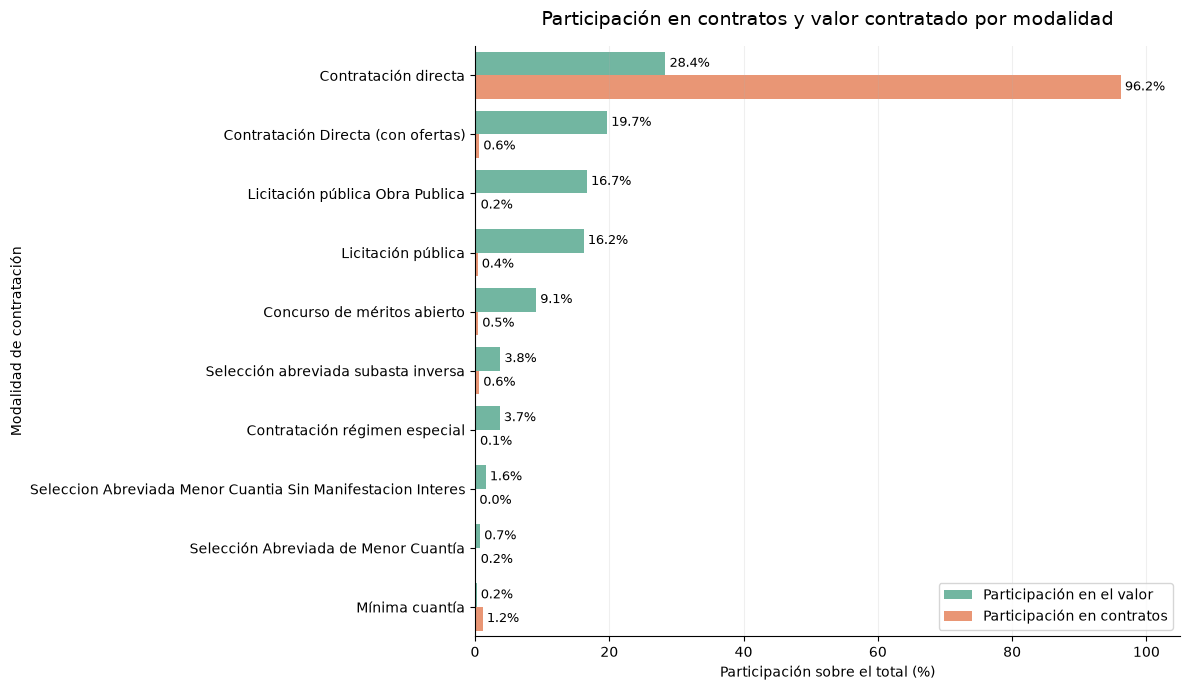

In [76]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=grafica_modalidad,
    y="modalidad_de_contratacion",
    x="participacion_pct",
    hue="indicador",
    order=orden_modalidades,
    palette="Set2"
)

plt.title(
    "Participación en contratos y valor contratado por modalidad",
    fontsize=14,
    pad=15
)

plt.xlabel("Participación sobre el total (%)")
plt.ylabel("Modalidad de contratación")

# Dejamos espacio para las etiquetas numéricas
plt.xlim(0, 105)

plt.grid(axis="x", alpha=0.2)

plt.legend(
    title="",
    loc="lower right"
)

# Agregar porcentaje al final de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación por modalidad de contratación

La comparación evidencia una diferencia importante entre la frecuencia contractual
y la concentración económica. La modalidad de `Contratación directa` representa
aproximadamente el 96,2 % de los contratos, pero concentra cerca del 28,4 % del valor
total contratado.

En contraste, modalidades como `Contratación Directa (con ofertas)`,
`Licitación pública Obra Pública` y `Licitación pública` representan individualmente
menos del 1 % del número de contratos, pero concentran aproximadamente el 19,7 %,
16,7 % y 16,2 % del valor, respectivamente.

Por lo tanto, una mayor frecuencia de contratación no implica necesariamente una
mayor concentración de los recursos contratados.

### Frecuencia de contratos vs. concentración del valor por tipo de contrato

Se compara la participación de cada tipo de contrato en el número total de contratos
con su participación en el valor total contratado.

Esta comparación permite identificar si los tipos de contrato más frecuentes son
también aquellos que concentran la mayor proporción de los recursos contratados.

In [77]:
grafica_tipo = resumen_tipo[
    [
        "tipo_de_contrato",
        "participacion_valor_pct",
        "participacion_contratos_pct"
    ]
].melt(
    id_vars="tipo_de_contrato",
    value_vars=[
        "participacion_valor_pct",
        "participacion_contratos_pct"
    ],
    var_name="indicador",
    value_name="participacion_pct"
)

In [78]:
grafica_tipo["indicador"] = grafica_tipo["indicador"].replace({
    "participacion_valor_pct": "Participación en el valor",
    "participacion_contratos_pct": "Participación en contratos"
})

In [79]:
orden_tipos = (
    resumen_tipo
    .sort_values("participacion_valor_pct", ascending=False)
    ["tipo_de_contrato"]
)

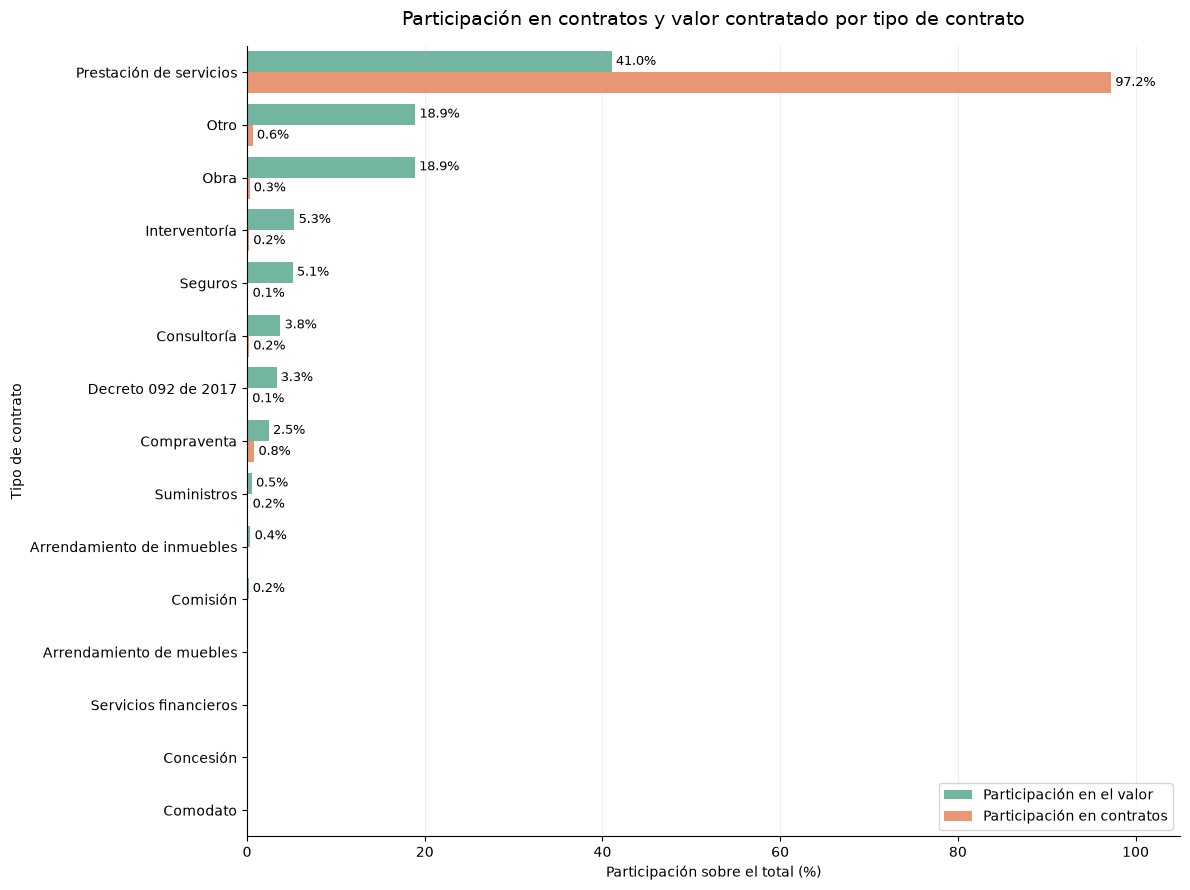

In [80]:
plt.figure(figsize=(12, 9))

ax = sns.barplot(
    data=grafica_tipo,
    y="tipo_de_contrato",
    x="participacion_pct",
    hue="indicador",
    order=orden_tipos,
    palette="Set2"
)

plt.title(
    "Participación en contratos y valor contratado por tipo de contrato",
    fontsize=14,
    pad=15
)

plt.xlabel("Participación sobre el total (%)")
plt.ylabel("Tipo de contrato")

plt.xlim(0, 105)
plt.grid(axis="x", alpha=0.2)

plt.legend(
    title="",
    loc="lower right"
)

for container in ax.containers:
    etiquetas = [
        f"{valor:.1f}%" if valor >= 0.1 else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=etiquetas,
        padding=3,
        fontsize=9
    )

sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación por tipo de contrato

La distribución por tipo de contrato evidencia una diferencia importante entre la frecuencia contractual y la concentración del valor contratado.

`Prestación de servicios` concentra aproximadamente el 97,2 % del número total de contratos, pero representa cerca del 41,0 % del valor contratado.

En contraste, categorías como `Otro` y `Obra` representan solamente alrededor del 0,6 % y 0,3 % de los contratos, respectivamente, pero cada una concentra cerca del 18,9 % del valor total.

Esto muestra que los tipos de contrato más frecuentes no necesariamente son los que concentran la mayor proporción de los recursos contratados. Por tanto, el análisis de frecuencia debe complementarse con el análisis del valor económico de la contratación.

Las participaciones inferiores al 0,1 % no se etiquetan en la figura para facilitar su lectura.

### Distribución del valor de los contratos

Se analiza la distribución del valor monetario de los contratos con el propósito de identificar los rangos en los que se concentra la mayor cantidad de observaciones.

Debido a la fuerte asimetría de `valor_del_contrato`, se utilizan los valores originales en pesos colombianos y únicamente la representación del eje horizontal se muestra en escala logarítmica. Esto facilita comparar contratos de distintos órdenes de magnitud sin transformar los datos originales.

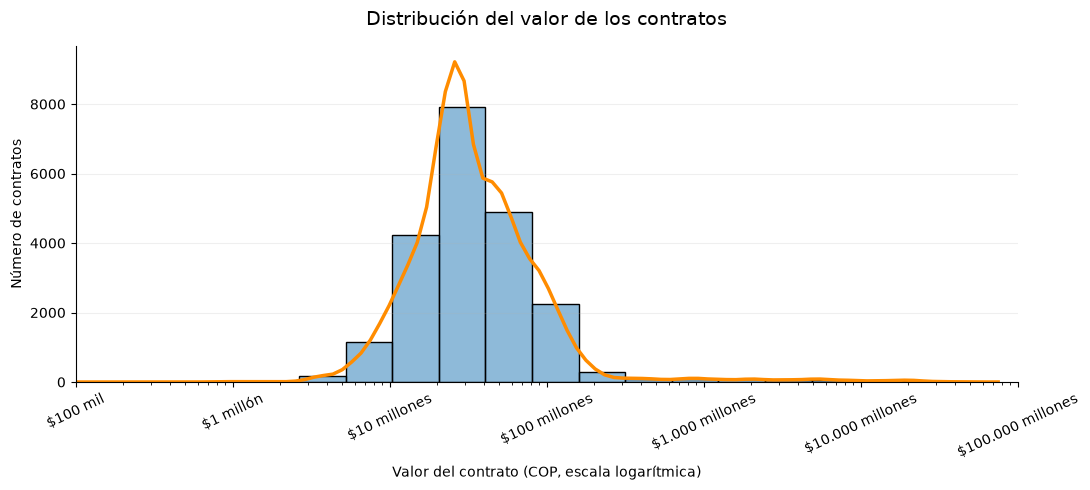

In [81]:
plt.figure(figsize=(11, 5))

ax = sns.histplot(
    data=df_monetario,
    x="valor_del_contrato",
    bins=40,
    kde=True,
    log_scale=True
)

# Cambiar únicamente el color de la curva suavizada
ax.lines[-1].set_color("darkorange")
ax.lines[-1].set_linewidth(2.5)

ticks = [
    100_000,
    1_000_000,
    10_000_000,
    100_000_000,
    1_000_000_000,
    10_000_000_000,
    100_000_000_000
]

labels = [
    "$100 mil",
    "$1 millón",
    "$10 millones",
    "$100 millones",
    "$1.000 millones",
    "$10.000 millones",
    "$100.000 millones"
]

plt.xticks(ticks, labels, rotation=25)

# Zoom de la visualización
plt.xlim(100_000, 100_000_000_000)

plt.title(
    "Distribución del valor de los contratos",
    fontsize=14,
    pad=15
)

plt.xlabel("Valor del contrato (COP, escala logarítmica)")
plt.ylabel("Número de contratos")

plt.grid(axis="y", alpha=0.2)
sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación de la distribución del valor contractual

El histograma muestra que la mayor cantidad de contratos se concentra en valores del
orden de decenas de millones de pesos. A medida que aumenta el valor contractual,
la frecuencia disminuye, aunque se observa una extensión de la distribución hacia
contratos de cientos y miles de millones de pesos.

Debido a la amplia diferencia entre los montos contractuales, el eje horizontal se
presenta en escala logarítmica. Los valores utilizados en la gráfica corresponden
directamente a `valor_del_contrato` en pesos colombianos; la escala logarítmica modifica
únicamente su representación visual y permite comparar contratos de diferentes órdenes
de magnitud sin alterar los datos originales.

La curva suavizada permite observar con mayor claridad la zona de mayor concentración
de los contratos y la extensión de la distribución hacia valores elevados.

Para facilitar la lectura de la distribución principal, la figura muestra valores desde
$100 mil. Los dos contratos con valores excepcionalmente bajos identificados previamente
permanecen en la base de datos, aunque no aparecen dentro del rango mostrado.

### Evolución temporal de la participación del valor por modalidad

Se analiza cómo ha cambiado la participación de cada modalidad de contratación en el
valor total contratado por año.

Para facilitar la comparación entre años y modalidades, se utiliza un mapa de calor,
donde cada celda representa el porcentaje del valor contratado en un año determinado
que corresponde a una modalidad específica.

El año 2026 corresponde a información parcial y, por lo tanto, debe interpretarse con
precaución.

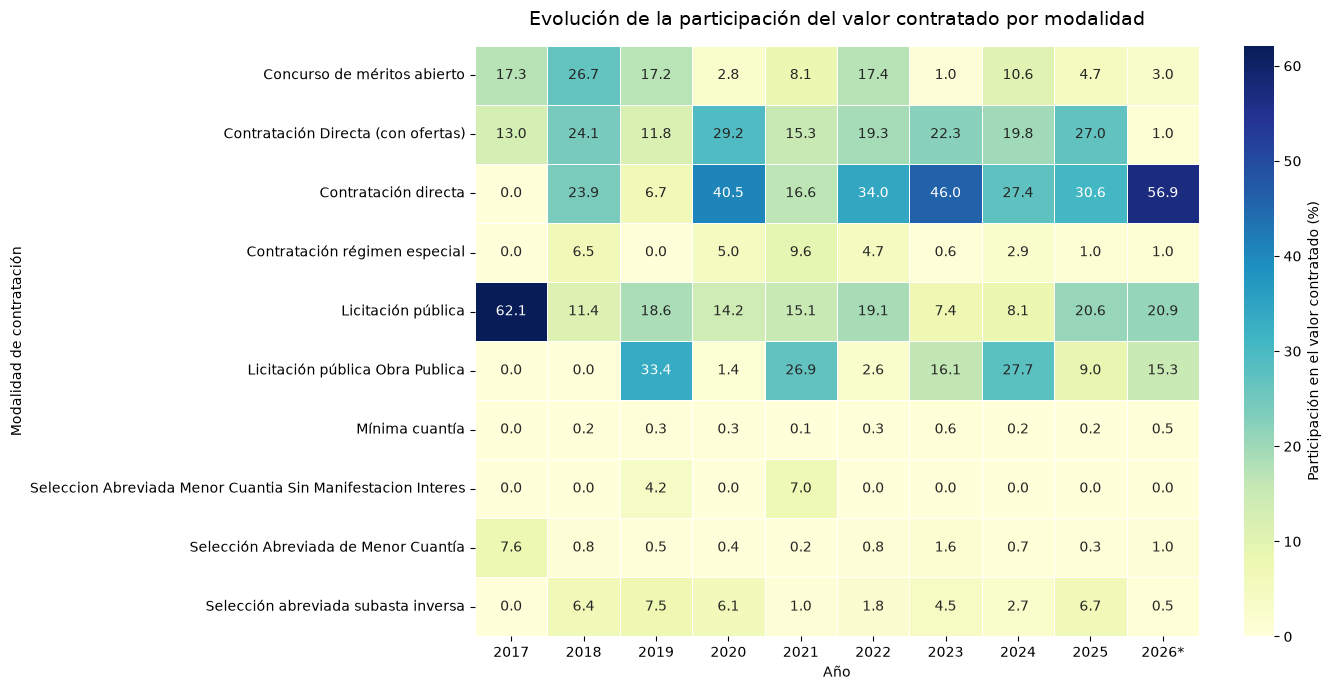

In [82]:
plt.figure(figsize=(14, 7))

ax = sns.heatmap(
    tabla_modalidad_anual.T,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={
        "label": "Participación en el valor contratado (%)"
    }
)

plt.title(
    "Evolución de la participación del valor contratado por modalidad",
    fontsize=14,
    pad=15
)

plt.xlabel("Año")
plt.ylabel("Modalidad de contratación")

# Identificar que 2026 corresponde a información parcial
ax.set_xticklabels(
    [
        str(año) if año != 2026 else "2026*"
        for año in tabla_modalidad_anual.index
    ],
    rotation=0
)

plt.tight_layout()
plt.show()

#### Interpretación de la evolución por modalidad

La composición del valor contratado por modalidad presenta variaciones importantes
a lo largo del tiempo, lo que indica que la concentración económica no se mantiene
estable entre años.

En 2017, la `Licitación pública` concentró aproximadamente el 62,1 % del valor
contratado. Posteriormente, otras modalidades adquirieron una mayor participación,
como `Licitación pública Obra Pública` en 2019 y 2021, con participaciones cercanas
al 33,4 % y 26,9 %, respectivamente.

La `Contratación directa` muestra un aumento relevante en varios años recientes,
alcanzando aproximadamente el 46,0 % del valor contratado en 2023 y el 56,9 % en 2026.

En conjunto, estos resultados muestran que la concentración del valor contratado
cambia de forma significativa entre modalidades y años, por lo que no existe una
estructura contractual constante durante todo el periodo analizado.

*El año 2026 corresponde a información parcial y debe interpretarse con precaución.*

### Evolución de las principales modalidades de contratación

Para complementar el mapa de calor, se analiza la evolución de las modalidades de
contratación que concentran la mayor participación del valor contratado durante el
periodo.

La gráfica permite observar con mayor claridad cómo ha cambiado el peso relativo de las
modalidades más relevantes dentro del valor contratado anualmente.

El año 2026 corresponde a información parcial y debe interpretarse con precaución.

In [83]:
modalidades_principales = [
    "Contratación directa",
    "Contratación Directa (con ofertas)",
    "Licitación pública Obra Publica"
]

evolucion_modalidades_principales = (
    evolucion_modalidad
    .pivot(
        index="año",
        columns="modalidad_de_contratacion",
        values="participacion_valor_pct"
    )
    .reindex(index=range(2017, 2027), columns=modalidades_principales)
    .fillna(0)
    .reset_index()
    .melt(
        id_vars="año",
        var_name="modalidad_de_contratacion",
        value_name="participacion_valor_pct"
    )
)

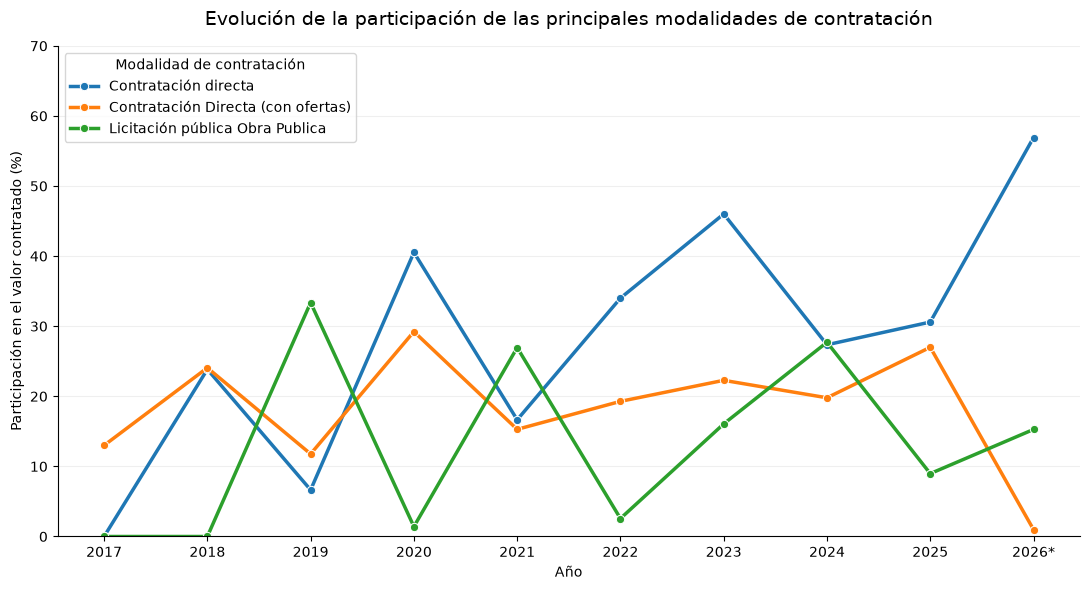

In [84]:
plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=evolucion_modalidades_principales,
    x="año",
    y="participacion_valor_pct",
    hue="modalidad_de_contratacion",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Evolución de la participación de las principales modalidades de contratación",
    fontsize=14,
    pad=15
)

plt.xlabel("Año")
plt.ylabel("Participación en el valor contratado (%)")

plt.xticks(
    range(2017, 2027),
    [str(año) if año != 2026 else "2026*" for año in range(2017, 2027)]
)

plt.ylim(0, 70)

plt.grid(axis="y", alpha=0.2)

plt.legend(title="Modalidad de contratación")

sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación de la evolución de las principales modalidades de contratación

Las tres modalidades con mayor participación acumulada en el valor contratado presentan
trayectorias diferentes a lo largo del periodo analizado.

`Contratación directa` adquiere un mayor protagonismo en los años recientes. Su
participación aumenta especialmente desde 2022 y alcanza aproximadamente el 46,0 % del
valor contratado en 2023. En 2026 llega al 56,9 %, aunque este último año corresponde a
información parcial.

`Contratación Directa (con ofertas)` presenta una participación más variable, con valores
relevantes en años como 2018, 2020, 2023 y 2025, pero sin mostrar una tendencia sostenida
de crecimiento o disminución durante todo el periodo.

Por su parte, `Licitación pública Obra Publica` se caracteriza por una mayor volatilidad:
concentra aproximadamente el 33,4 % del valor contratado en 2019 y el 26,9 % en 2021,
mientras que en otros años su participación es considerablemente menor.

En conjunto, la gráfica evidencia que la composición del valor contratado entre las
principales modalidades cambia de forma importante entre años. En particular, `Contratación directa` presenta una participación económica relevante
en varios de los años recientes, mientras que las otras modalidades presentan
comportamientos más fluctuantes.

*El año 2026 corresponde a información parcial y debe interpretarse con precaución.*

### Evolución temporal de la participación del valor por tipo de contrato

Se analiza cómo ha cambiado la participación de cada tipo de contrato en el valor total
contratado a lo largo del tiempo.

El mapa de calor permite identificar los tipos de contrato que han concentrado una mayor
proporción de los recursos en cada año y observar cambios en la composición de la
contratación.

El año 2026 corresponde a información parcial y debe interpretarse con precaución.

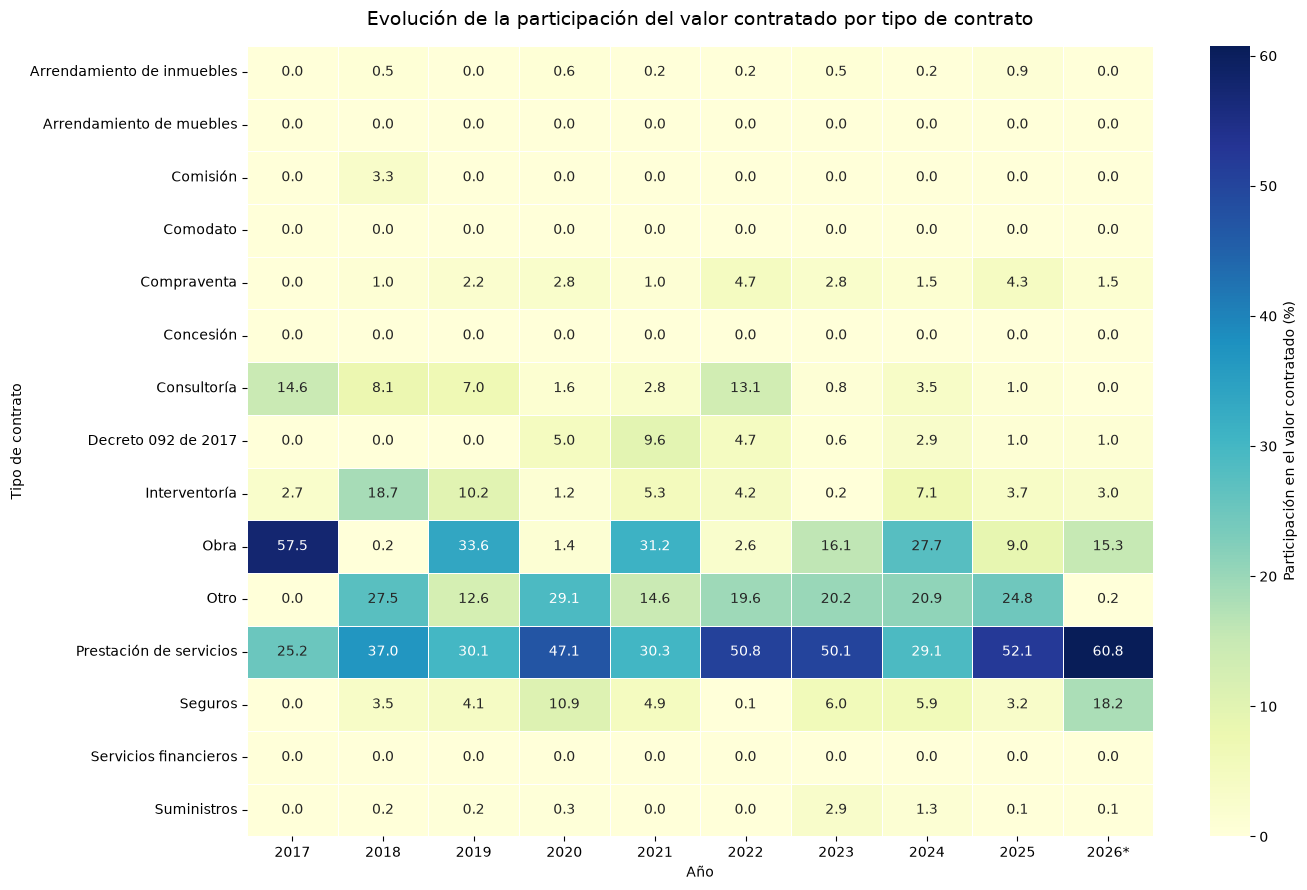

In [85]:
plt.figure(figsize=(14, 9))

ax = sns.heatmap(
    tabla_tipo_anual.T,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={
        "label": "Participación en el valor contratado (%)"
    }
)

plt.title(
    "Evolución de la participación del valor contratado por tipo de contrato",
    fontsize=14,
    pad=15
)

plt.xlabel("Año")
plt.ylabel("Tipo de contrato")

# Identificar que 2026 corresponde a información parcial
ax.set_xticklabels(
    [
        str(año) if año != 2026 else "2026*"
        for año in tabla_tipo_anual.index
    ],
    rotation=0
)

plt.tight_layout()
plt.show()

#### Interpretación de la evolución por tipo de contrato

La composición del valor contratado por tipo de contrato presenta cambios importantes
entre años, aunque se observa una participación recurrentemente alta de
`Prestación de servicios`.

Este tipo de contrato concentra una proporción relevante del valor contratado en la
mayoría de los años analizados, alcanzando aproximadamente 47,1 % en 2020, 50,8 % en
2022, 50,1 % en 2023, 52,1 % en 2025 y 60,8 % en 2026.

El tipo `Obra` también muestra una participación importante en algunos años,
especialmente en 2017 (57,5 %), 2019 (33,6 %) y 2021 (31,2 %), aunque su peso relativo
disminuye en otros periodos.

Por su parte, la categoría `Otro` mantiene una participación considerable en varios
años, como 2018, 2020, 2023 y 2025, lo que sugiere una composición contractual más
diversificada en esos periodos.

En conjunto, los resultados muestran que la concentración del valor contratado por tipo
de contrato no es estable a lo largo del tiempo, aunque `Prestación de servicios`
aparece como la categoría con mayor predominio en varios años recientes.

*El año 2026 corresponde a información parcial y debe interpretarse con precaución.*

### Evolución de los principales tipos de contrato

Para complementar el mapa de calor, se analiza la evolución de los tres tipos de
contrato que concentran la mayor participación del valor contratado durante el periodo:
`Prestación de servicios`, `Otro` y `Obra`.

La gráfica permite observar con mayor claridad cómo ha cambiado el peso relativo de
estas categorías dentro del valor contratado anualmente.

El año 2026 corresponde a información parcial y debe interpretarse con precaución.

In [86]:
tipos_principales = [
    "Prestación de servicios",
    "Otro",
    "Obra"
]

evolucion_tipos_principales = (
    evolucion_tipo
    .pivot(
        index="año",
        columns="tipo_de_contrato",
        values="participacion_valor_pct"
    )
    .reindex(index=range(2017, 2027), columns=tipos_principales)
    .fillna(0)
    .reset_index()
    .melt(
        id_vars="año",
        var_name="tipo_de_contrato",
        value_name="participacion_valor_pct"
    )
)

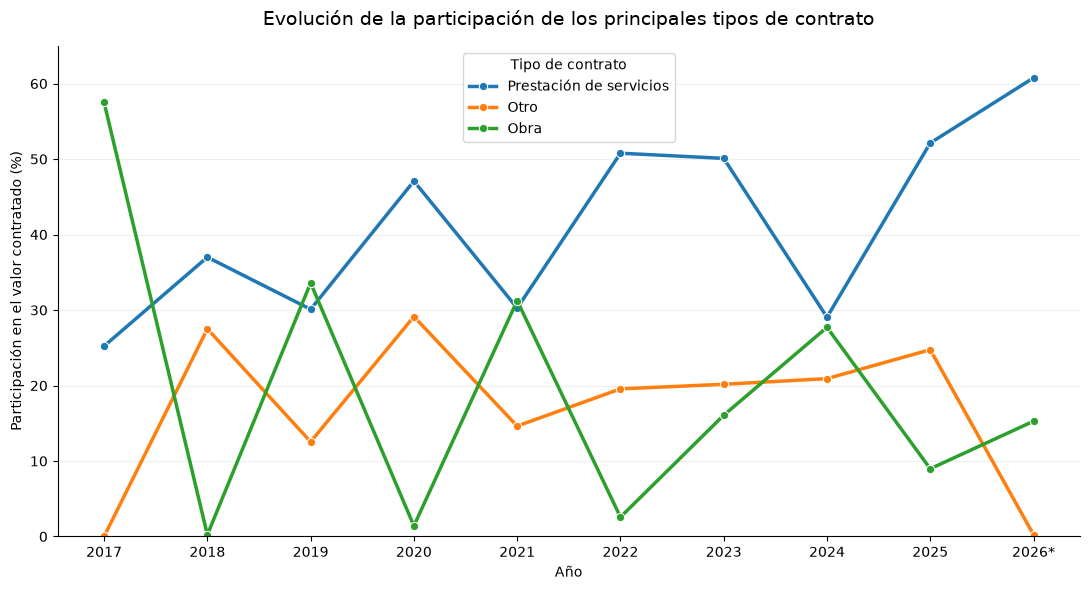

In [87]:
plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=evolucion_tipos_principales,
    x="año",
    y="participacion_valor_pct",
    hue="tipo_de_contrato",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Evolución de la participación de los principales tipos de contrato",
    fontsize=14,
    pad=15
)

plt.xlabel("Año")
plt.ylabel("Participación en el valor contratado (%)")

plt.xticks(
    range(2017, 2027),
    [str(año) if año != 2026 else "2026*" for año in range(2017, 2027)]
)

plt.ylim(0, 65)

plt.grid(axis="y", alpha=0.2)

plt.legend(
    title="Tipo de contrato"
)

sns.despine()

plt.tight_layout()
plt.show()

#### Interpretación de la evolución de los principales tipos de contrato

La evolución temporal muestra comportamientos diferentes entre los tres tipos de contrato
que concentran la mayor proporción del valor contratado.

`Prestación de servicios` presenta una participación elevada en varios de los años
recientes y supera el 50 % del valor contratado en 2022, 2023 y 2025. En contraste,
`Obra` muestra una mayor variabilidad, con participaciones especialmente altas en 2017,
2019, 2021 y 2024, pero considerablemente menores en otros años.

La categoría `Otro` mantiene una participación relevante durante buena parte del periodo,
aunque con fluctuaciones entre años.

En conjunto, la gráfica evidencia un cambio en la composición del valor contratado:
mientras que en algunos años el valor se encontraba fuertemente concentrado en contratos
de obra, en los años recientes adquieren mayor predominio los contratos de
`Prestación de servicios`.

*El año 2026 corresponde a información parcial y debe interpretarse con precaución.*

## 6. Análisis estadístico

### Diferencias en el valor contractual entre modalidades de contratación

Dada la fuerte asimetría observada en `valor_del_contrato` y la presencia de valores
atípicos superiores, se utiliza la prueba no paramétrica de Kruskal-Wallis para evaluar
si existen diferencias estadísticamente significativas en la distribución del valor
de los contratos entre las distintas modalidades de contratación.

Las hipótesis planteadas son:

- **H₀:** la distribución del valor contractual es igual entre las modalidades de contratación.
- **H₁:** al menos una modalidad presenta una distribución del valor contractual diferente.

In [88]:
from scipy.stats import kruskal

grupos_modalidad = [
    grupo["valor_del_contrato"].values
    for _, grupo in df_monetario.groupby("modalidad_de_contratacion")
]

estadistico_kw, p_valor_kw = kruskal(*grupos_modalidad)

print(f"Estadístico de Kruskal-Wallis: {estadistico_kw:.4f}")
print(f"P-valor: {p_valor_kw:.6f}")

Estadístico de Kruskal-Wallis: 1482.1589
P-valor: 0.000000


#### Resultado de la prueba de Kruskal-Wallis por modalidad

La prueba de Kruskal-Wallis obtuvo un estadístico de **1482,16** y un valor
*p* inferior a **0,001**.

Dado que el valor *p* es menor al nivel de significancia de 0,05, se rechaza la
hipótesis nula. Por lo tanto, existe evidencia estadísticamente significativa de que
la distribución del valor contractual no es igual entre todas las modalidades de
contratación.

Este resultado complementa el análisis descriptivo y visual, en el que se observaron
diferencias importantes en los montos asociados a las distintas modalidades.

La prueba permite concluir que al menos una modalidad presenta una distribución del
valor contractual diferente, aunque no identifica específicamente entre qué pares de
modalidades se encuentran dichas diferencias.

### Diferencias en el valor contractual entre tipos de contrato

Se utiliza nuevamente la prueba no paramétrica de Kruskal-Wallis para evaluar si
existen diferencias estadísticamente significativas en la distribución del valor
contractual entre los distintos tipos de contrato.

Debido a que algunas categorías presentan un número muy reducido de observaciones,
la prueba se realiza únicamente sobre los tipos de contrato que cuentan con al menos
cinco contratos con valor positivo. Esta restricción se aplica únicamente para la
prueba estadística y no elimina dichas categorías del análisis descriptivo.

Las hipótesis planteadas son:

- **H₀:** la distribución del valor contractual es igual entre los tipos de contrato analizados.
- **H₁:** al menos un tipo de contrato presenta una distribución del valor contractual diferente.

In [89]:
conteo_tipos = (
    df_monetario["tipo_de_contrato"]
    .value_counts()
    .sort_values(ascending=False)
)

conteo_tipos

tipo_de_contrato
Prestación de servicios       20791
Compraventa                     175
Otro                            122
Obra                             59
Interventoría                    50
Consultoría                      45
Suministros                      33
Seguros                          32
Decreto 092 de 2017              23
Arrendamiento de inmuebles       19
Arrendamiento de muebles          3
Servicios financieros             2
Concesión                         1
Comisión                          1
Name: count, dtype: int64

In [90]:
tipos_validos = conteo_tipos[
    conteo_tipos >= 5
].index

df_prueba_tipo = df_monetario[
    df_monetario["tipo_de_contrato"].isin(tipos_validos)
].copy()

grupos_tipo = [
    grupo["valor_del_contrato"].values
    for _, grupo in df_prueba_tipo.groupby("tipo_de_contrato")
]

estadistico_kw_tipo, p_valor_kw_tipo = kruskal(*grupos_tipo)

print(f"Número de tipos incluidos: {len(tipos_validos)}")
print(f"Estadístico de Kruskal-Wallis: {estadistico_kw_tipo:.4f}")
print(f"P-valor: {p_valor_kw_tipo:.6f}")

Número de tipos incluidos: 10
Estadístico de Kruskal-Wallis: 950.5776
P-valor: 0.000000


#### Resultado de la prueba de Kruskal-Wallis por tipo de contrato

Para la prueba se incluyeron 10 tipos de contrato que cuentan con al menos cinco
observaciones con valor contractual positivo. Las categorías con menor número de
observaciones se mantienen en el análisis descriptivo, pero no se incluyen en esta
comparación estadística.

La prueba de Kruskal-Wallis obtuvo un estadístico de **950,58** y un valor *p*
inferior a **0,001**.

Dado que el valor *p* es menor al nivel de significancia de 0,05, se rechaza la
hipótesis nula. Por lo tanto, existe evidencia estadísticamente significativa de que
el valor contractual presenta diferencias entre los tipos de contrato analizados.

Este resultado es consistente con el análisis descriptivo y visual, en el que se
observaron diferencias importantes entre categorías como `Prestación de servicios`,
`Obra`, `Otro`, `Interventoría` y otros tipos de contrato.

La prueba permite concluir que al menos un tipo de contrato presenta un comportamiento
diferente en términos del valor contractual, aunque no permite identificar
específicamente entre qué pares de categorías se encuentran dichas diferencias.

## 7. Conclusiones del análisis

El análisis evidencia que la frecuencia con la que se utiliza una modalidad o tipo de
contrato no necesariamente coincide con la proporción del valor económico que concentra.

Por modalidad de contratación, `Contratación directa` representa aproximadamente el
96,2 % del número de contratos, pero concentra cerca del 28,4 % del valor total contratado.
En contraste, `Contratación Directa (con ofertas)` representa menos del 1 % de los
contratos y concentra aproximadamente el 19,7 % del valor. De manera similar,
`Licitación pública Obra Publica` concentra cerca del 16,7 % del valor contratado a
pesar de representar una proporción muy reducida del número de contratos.

Por tipo de contrato, `Prestación de servicios` domina ampliamente en frecuencia,
con aproximadamente el 97,2 % de los contratos, pero representa cerca del 41,0 % del
valor contratado. Los tipos `Otro` y `Obra`, aunque representan individualmente menos
del 1 % del número de contratos, concentran aproximadamente el 18,9 % del valor cada uno.

El análisis temporal muestra además que esta composición no permanece constante.
La participación económica de las distintas modalidades y tipos de contrato presenta
variaciones importantes entre años. En los años recientes se observa un mayor peso de
`Contratación directa` entre las modalidades y de `Prestación de servicios` entre los
tipos de contrato, aunque existen años en los que categorías como `Obra` o
`Licitación pública Obra Publica` adquieren una participación considerable.

Las pruebas de Kruskal-Wallis complementan estos resultados. Se encontró evidencia
estadísticamente significativa de diferencias en la distribución del valor contractual
tanto entre modalidades de contratación como entre los tipos de contrato analizados
(p < 0,001 en ambos casos).

En conjunto, los resultados muestran que la contratación de la Secretaría Distrital
de Movilidad se caracteriza por una alta concentración en términos de frecuencia en
pocas categorías, pero una distribución del valor económico considerablemente más
diversificada y variable a lo largo del tiempo.

*El año 2026 contiene información parcial y, por lo tanto, sus resultados deben
interpretarse con precaución.*